# Přehled výkonu reklamních webů

## 1. Analytický postup a kontrola dat
V první části se seznamuji se strukturou datasetu a ověřuji jeho kvalitu před samotnou analýzou.

Kontroluji zejména:
- rozsah a strukturu dat,
- datové typy jednotlivých proměnných,
- případné chybějící nebo duplicitní záznamy,
- hodnoty obsažené v hlavních kategoriálních dimenzích.

Cíl - ověřit, že následné agregace a výpočty vycházejí ze správně interpretovaných dat a že případné nedostatky datasetu jsou předem identifikované.

**Tato část by nebyla prezentována managementu.**


### 1.1 Načtení a základní struktura datasetu


Import knihoven

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

Načtení dat

In [7]:
df = pd.read_csv('sklik_overview_sample.csv')

Základní struktura dat

In [8]:
df.head()

,DATE,WEB_NAME,NETWORK,DEVICE_TYPE,OPERATING_SYSTEM,GENDER,AGE_GROUP,KRAJ,IMPRESSIONS,CLICKS,CONVERSIONS,CONVERSION_VALUE,MONEY
0,2026-07-26,Aktualitky.cz,context,Desktop,ChromeOS,Žena,40 - 59,Hlavní město Praha,87,0,0,0.0,0.93
1,2026-07-26,Aktualitky.cz,context,Desktop,ChromeOS,Žena,40 - 59,Středočeský kraj,16,0,0,0.0,0.17
2,2026-07-26,Aktualitky.cz,context,Desktop,ChromeOS,Žena,40 - 59,Jihočeský kraj,57,0,0,0.0,0.61
3,2026-07-26,Aktualitky.cz,context,Desktop,ChromeOS,Žena,40 - 59,Plzeňský kraj,52,0,0,0.0,0.55
4,2026-07-26,Aktualitky.cz,context,Desktop,ChromeOS,Žena,40 - 59,Karlovarský kraj,14,0,0,0.0,0.15


In [9]:
print(f"Počet řádků: {df.shape[0]:,}")
print(f"Počet sloupců: {df.shape[1]}")

Počet řádků: 9,996
Počet sloupců: 13


### 1.2 Kontrola datových typů
Cílem je zjistit datové typy a provést jejich kontrolu.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9996 entries, 0 to 9995
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   DATE              9996 non-null   object 
 1   WEB_NAME          9996 non-null   object 
 2   NETWORK           9996 non-null   object 
 3   DEVICE_TYPE       9520 non-null   object 
 4   OPERATING_SYSTEM  7028 non-null   object 
 5   GENDER            9996 non-null   object 
 6   AGE_GROUP         9996 non-null   object 
 7   KRAJ              9996 non-null   object 
 8   IMPRESSIONS       9996 non-null   int64  
 9   CLICKS            9996 non-null   int64  
 10  CONVERSIONS       9996 non-null   int64  
 11  CONVERSION_VALUE  9996 non-null   float64
 12  MONEY             9996 non-null   float64
dtypes: float64(2), int64(3), object(8)
memory usage: 1015.3+ KB


Sloupec DATE převádím na datový typ datetime, aby bylo možné s datem správně pracovat při filtrování, řazení a případných časových agregacích.

In [11]:
df['DATE'] = pd.to_datetime(df['DATE'])

In [12]:
df['DATE'].dtype

dtype('<M8[ns]')

### 1.3 Chybějící hodnoty a duplicity
Cílem je najít případné chybějící hodnoty a duplicity.

In [13]:
missing_values = df.isna().sum()
missing_values

,0
DATE,0
WEB_NAME,0
NETWORK,0
DEVICE_TYPE,476
OPERATING_SYSTEM,2968
GENDER,0
AGE_GROUP,0
KRAJ,0
IMPRESSIONS,0
CLICKS,0


In [14]:
missing_share = (df.isna().mean() * 100).round(2)

pd.DataFrame({
    'missing_values': missing_values,
    'missing_share_%': missing_share
})

,missing_values,missing_share_%
DATE,0,0.00
WEB_NAME,0,0.00
NETWORK,0,0.00
DEVICE_TYPE,476,4.76
OPERATING_SYSTEM,2968,29.69
GENDER,0,0.00
AGE_GROUP,0,0.00
KRAJ,0,0.00
IMPRESSIONS,0,0.00
CLICKS,0,0.00


Ve sloupci OPERATING_SYSTEM chybí 29,69 % hodnot a ve sloupci DEVICE_TYPE 4,76 %. V této fázi neznáme příčinu chybějících dat, proto je bez dalšího ověření není vhodné mazat ani doplňovat. Pro aktuální přehled je ponecháváme beze změny a při případných navazujících analýzách podle operačního systému nebo typu zařízení je potřeba s tímto omezením počítat.

In [15]:
duplicate_rows = df.duplicated().sum()
duplicate_rows

np.int64(0)

V datasetu se nenachází duplicitní řádky.

### 1.4 Pochopení dimenzí a granularita dat
Dataset obsahuje výkonnostní metriky rozdělené podle několika dimenzí.
Před agregací je proto důležité ověřit, jaké hodnoty jednotlivé dimenze obsahují a na jaké úrovni je jeden řádek dat zaznamenán.

In [16]:
categorical_columns = [
    'WEB_NAME',
    'NETWORK',
    'DEVICE_TYPE',
    'OPERATING_SYSTEM',
    'GENDER',
    'AGE_GROUP',
    'KRAJ'
]

for col in categorical_columns:
    print(f"\n{col}")
    print(f"Počet unikátních hodnot: {df[col].nunique(dropna=False)}")
    print(df[col].unique())


WEB_NAME
Počet unikátních hodnot: 10
['Aktualitky.cz' 'Baráky.cz' 'Blogeria.cz' 'Drbárna.cz' 'Kliknito.cz'
 'Kopačka.cz' 'Kámoši.net' 'Pozdní Zprávy' 'ProTety.cz' 'Poštovna.cz']

NETWORK
Počet unikátních hodnot: 1
['context']

DEVICE_TYPE
Počet unikátních hodnot: 11
['Desktop' 'Tablet' 'Mobile' 'SmartPhone' 'MediaHub' 'Tv' nan
 'SmallScreen' 'Console' 'EReader' 'SmartWatch']

OPERATING_SYSTEM
Počet unikátních hodnot: 9
['ChromeOS' nan 'Android' 'macOS' 'Windows' 'Tizen' 'iPadOS' 'iOS'
 'Ubuntu']

GENDER
Počet unikátních hodnot: 3
['Žena' 'Muž' 'Neznámý']

AGE_GROUP
Počet unikátních hodnot: 5
['40 - 59' 'Neznámý' '60+' '18 - 24' '25 - 39']

KRAJ
Počet unikátních hodnot: 14
['Hlavní město Praha' 'Středočeský kraj' 'Jihočeský kraj' 'Plzeňský kraj'
 'Karlovarský kraj' 'Ústecký kraj' 'Liberecký kraj' 'Královéhradecký kraj'
 'Pardubický kraj' 'Kraj Vysočina' 'Jihomoravský kraj' 'Olomoucký kraj'
 'Zlínský kraj' 'Moravskoslezský kraj']


S jakým obdobím a počtem webů pracujeme

In [17]:
print(f"Období: {df['DATE'].min().strftime('%d.%m.%Y')} – {df['DATE'].max().strftime('%d.%m.%Y')}")
print(f"Počet webů: {df['WEB_NAME'].nunique()}")


Období: 26.07.2026 – 24.08.2026
Počet webů: 10


### 1.5 Výpočet odvozených metrik
Pro dopočítání základních poměrových metrik, které umožňují hodnotit efektivitu reklamního výkonu mezi jednotlivými weby.

In [18]:
web_summary = (
    df.groupby('WEB_NAME', as_index=False)
      .agg(
          impressions=('IMPRESSIONS', 'sum'),
          clicks=('CLICKS', 'sum'),
          conversions=('CONVERSIONS', 'sum'),
          conversion_value=('CONVERSION_VALUE', 'sum'),
          money=('MONEY', 'sum')
      )
)

- CTR = Click Through Rate = podíl kliků z impresí
- CVR = Conversion Rate = podíl konverzí z kliků
- CPC = Cost per Click = průměrná cena za klik
- CPA = Cost per Acquisition = průměrný náklad na konverzi
- ROAS = Return on Ad Spend = hodnota konverzí / náklady

In [19]:
web_summary['ctr'] = web_summary['clicks'] / web_summary['impressions'] * 100
web_summary['cvr'] = web_summary['conversions'] / web_summary['clicks'] * 100
web_summary['cpc'] = web_summary['money'] / web_summary['clicks']
web_summary['cpa'] = web_summary['money'] / web_summary['conversions']
web_summary['roas'] = web_summary['conversion_value'] / web_summary['money']

In [20]:
web_summary.round({
    'ctr': 2,
    'cvr': 2,
    'cpc': 2,
    'cpa': 2,
    'roas': 2
})

,WEB_NAME,impressions,clicks,conversions,conversion_value,money,ctr,cvr,cpc,cpa,roas
0,Aktualitky.cz,4696410,12087,804,457857.13,63708.41,0.26,6.65,5.27,79.24,7.19
1,Baráky.cz,2223362,10000,65,12673.23,32734.33,0.45,0.65,3.27,503.61,0.39
2,Blogeria.cz,1675024,3911,191,19941.21,17294.10,0.23,4.88,4.42,90.55,1.15
3,Drbárna.cz,8484597,23425,1090,1061727.52,111831.60,0.28,4.65,4.77,102.60,9.49
4,Kliknito.cz,16988559,105378,5035,1977727.82,432067.22,0.62,4.78,4.10,85.81,4.58
5,Kopačka.cz,2312011,3731,168,6743.42,20744.37,0.16,4.50,5.56,123.48,0.33
6,Kámoši.net,4233197,13022,800,297897.44,51777.10,0.31,6.14,3.98,64.72,5.75
7,Pozdní Zprávy,15131515,44444,2409,883428.70,221056.24,0.29,5.42,4.97,91.76,4.00
8,Poštovna.cz,1897695,3857,160,190527.84,27290.35,0.20,4.15,7.08,170.56,6.98
9,ProTety.cz,360605,1679,105,11242.16,7883.12,0.47,6.25,4.70,75.08,1.43


## 2. Business přehled pro produktového manažera
Výstup je zaměřen především na srozumitelnou interpretaci výsledků.

### 2.1 Co dataset pokrývá
Analyzovaný vzorek obsahuje data o výkonu reklamních webů za období **26. 7. 2026 až 24. 8. 2026**.

Dataset zahrnuje **10 webů** a sleduje jejich výkon pomocí základních reklamních a konverzních metrik, zejména:
- imprese,
- kliky,
- konverze,
- hodnotu konverzí,
- náklady.

Data zároveň umožňují výkon dále členit například podle reklamní sítě, zařízení, operačního systému, pohlaví, věkové skupiny nebo kraje.

In [21]:
print(f"Období: {df['DATE'].min().strftime('%d.%m.%Y')} – {df['DATE'].max().strftime('%d.%m.%Y')}")
print(f"Počet webů: {df['WEB_NAME'].nunique()}")
print(f"Počet záznamů: {len(df):,}")

Období: 26.07.2026 – 24.08.2026
Počet webů: 10
Počet záznamů: 9,996


### 2.2 Celkový výkon
Základní objemové metriky a několik odvozených ukazatelů, které pomáhají zasadit výkon do kontextu.

In [22]:
total_impressions = df['IMPRESSIONS'].sum()
total_clicks = df['CLICKS'].sum()
total_conversions = df['CONVERSIONS'].sum()
total_conversion_value = df['CONVERSION_VALUE'].sum()
total_money = df['MONEY'].sum()

total_ctr = total_clicks / total_impressions * 100
total_cvr = total_conversions / total_clicks * 100
total_cpc = total_money / total_clicks
total_cpa = total_money / total_conversions
total_roas = total_conversion_value / total_money

- CTR = Click Through Rate = podíl kliků z impresí
- CVR = Conversion Rate = podíl konverzí z kliků
- CPC = Cost per Click = průměrná cena za klik
- CPA = Cost per Acquisition = průměrný náklad na konverzi
- ROAS = Return on Ad Spend = hodnota konverzí / náklady

In [23]:
summary_kpis = pd.DataFrame({
    'Metrika': [
        'Imprese',
        'Kliky',
        'Konverze',
        'Náklady',
        'Hodnota konverzí',
        'CTR',
        'CVR',
        'CPC',
        'CPA',
        'ROAS'
    ],
    'Hodnota': [
        f"{total_impressions:,.0f}",
        f"{total_clicks:,.0f}",
        f"{total_conversions:,.0f}",
        f"{total_money:,.2f}",
        f"{total_conversion_value:,.2f}",
        f"{total_ctr:.2f} %",
        f"{total_cvr:.2f} %",
        f"{total_cpc:.2f}",
        f"{total_cpa:.2f}",
        f"{total_roas:.2f}"
    ]
})

summary_kpis

,Metrika,Hodnota
0,Imprese,"58,002,975"
1,Kliky,"221,534"
2,Konverze,"10,827"
3,Náklady,"986,386.84"
4,Hodnota konverzí,"4,919,766.47"
5,CTR,0.38 %
6,CVR,4.89 %
7,CPC,4.45
8,CPA,91.10
9,ROAS,4.99


Za sledované období reklama vygenerovala přibližně **58 mil. impresí**,
**221 tis. kliků** a **10,8 tis. konverzí**.

Při celkových nákladech zhruba **986 tis.** dosáhla hodnota konverzí
přibližně **4,92 mil.**, což odpovídá celkovému **ROAS 4,99**.


### 2.3 Srovnání webů
Jednotlivé weby se výrazně liší velikostí i množstvím generovaných výsledků.
Pro základní srovnání proto sleduji počet konverzí, který ukazuje, které weby přispívají k celkovému výsledku největším objemem.

In [24]:
web_conversions = web_summary.sort_values(
    'conversions',
    ascending=True
)

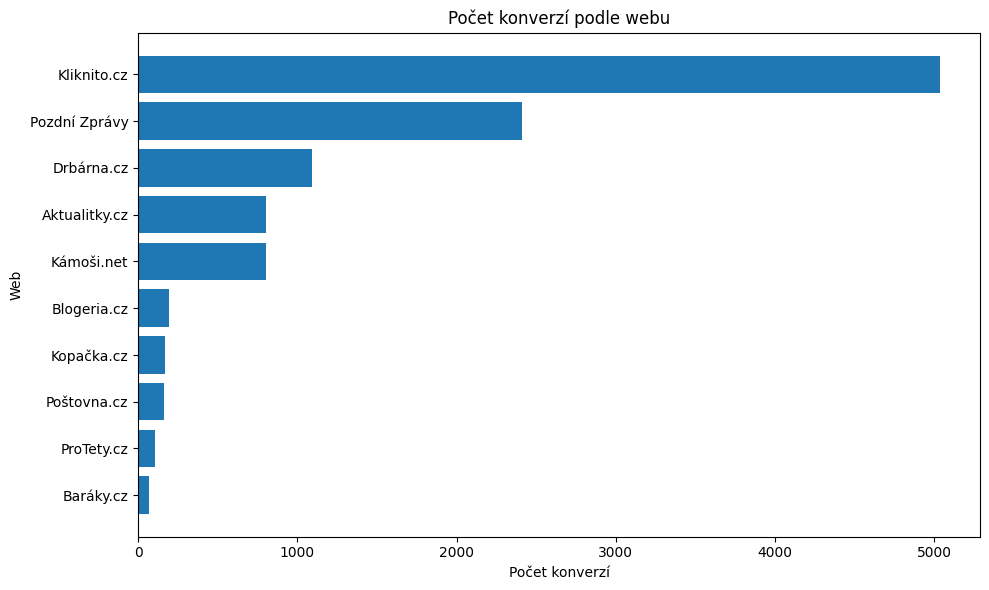

In [25]:
plt.figure(figsize=(10, 6))

plt.barh(
    web_conversions['WEB_NAME'],
    web_conversions['conversions']
)

plt.title('Počet konverzí podle webu')
plt.xlabel('Počet konverzí')
plt.ylabel('Web')

plt.tight_layout()
plt.show()

In [26]:
web_conversions_table = (
    web_summary[['WEB_NAME', 'conversions']]
    .copy()
)

web_conversions_table['share_of_conversions_%'] = (
    web_conversions_table['conversions']
    / web_conversions_table['conversions'].sum()
    * 100
)

web_conversions_table = web_conversions_table.sort_values(
    'conversions',
    ascending=False
)

web_conversions_table.round(2)

,WEB_NAME,conversions,share_of_conversions_%
4,Kliknito.cz,5035,46.50
7,Pozdní Zprávy,2409,22.25
3,Drbárna.cz,1090,10.07
0,Aktualitky.cz,804,7.43
6,Kámoši.net,800,7.39
2,Blogeria.cz,191,1.76
5,Kopačka.cz,168,1.55
8,Poštovna.cz,160,1.48
9,ProTety.cz,105,0.97
1,Baráky.cz,65,0.60


Největší počet konverzí generuje **Kliknito.cz**, následované weby
**Pozdní Zprávy** a **Drbárna.cz**. Několik nejsilnějších webů tak tvoří
významnou část celkového konverzního objemu.

Samotný počet konverzí ale ještě neříká, zda je tento výkon také nákladově efektivní, a proto je potřeba porovnat weby i podle efektivity.

### 2.4 Efektivita webů

Vysoký počet konverzí nemusí automaticky znamenat efektivní výkon.
Proto porovnávám jednotlivé weby pomocí metriky **ROAS**, která vyjadřuje poměr hodnoty konverzí k vynaloženým nákladům. Vyšší ROAS znamená, že web při stejném objemu nákladů generuje vyšší hodnotu konverzí.

In [27]:
web_roas = web_summary.sort_values(
    'roas',
    ascending=True
)

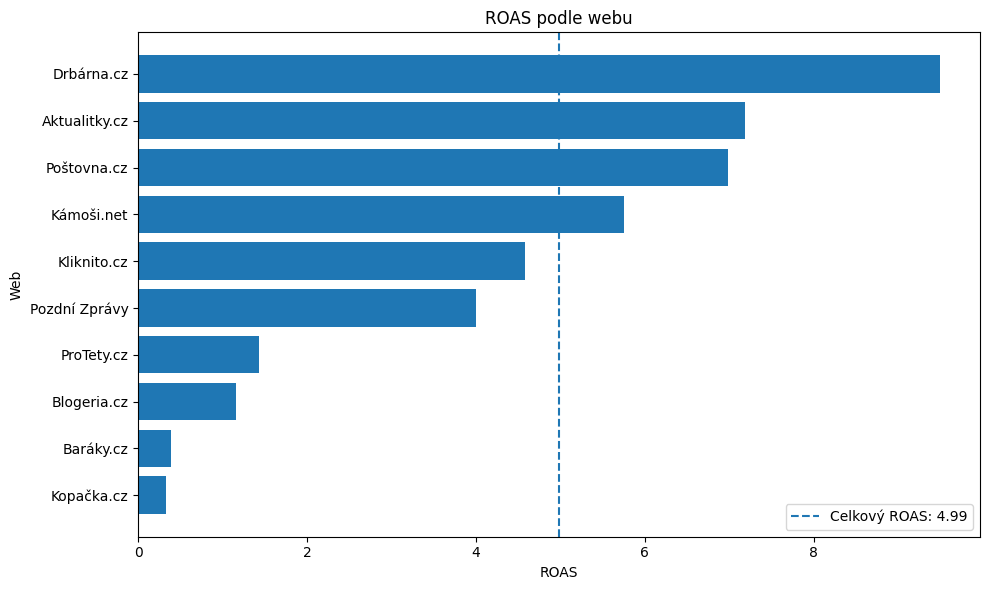

In [28]:
plt.figure(figsize=(10, 6))

plt.barh(
    web_roas['WEB_NAME'],
    web_roas['roas']
)

plt.axvline(
    total_roas,
    linestyle='--',
    label=f'Celkový ROAS: {total_roas:.2f}'
)

plt.title('ROAS podle webu')
plt.xlabel('ROAS')
plt.ylabel('Web')
plt.legend()

plt.tight_layout()
plt.show()

In [29]:
web_efficiency = (
    web_summary[
        ['WEB_NAME', 'conversions', 'money', 'conversion_value', 'roas', 'cpa']
    ]
    .sort_values('roas', ascending=False)
    .copy()
)

web_efficiency.round({
    'money': 2,
    'conversion_value': 2,
    'roas': 2,
    'cpa': 2
})

,WEB_NAME,conversions,money,conversion_value,roas,cpa
3,Drbárna.cz,1090,111831.60,1061727.52,9.49,102.60
0,Aktualitky.cz,804,63708.41,457857.13,7.19,79.24
8,Poštovna.cz,160,27290.35,190527.84,6.98,170.56
6,Kámoši.net,800,51777.10,297897.44,5.75,64.72
4,Kliknito.cz,5035,432067.22,1977727.82,4.58,85.81
7,Pozdní Zprávy,2409,221056.24,883428.70,4.00,91.76
9,ProTety.cz,105,7883.12,11242.16,1.43,75.08
2,Blogeria.cz,191,17294.10,19941.21,1.15,90.55
1,Baráky.cz,65,32734.33,12673.23,0.39,503.61
5,Kopačka.cz,168,20744.37,6743.42,0.33,123.48


Nejvyšší efektivitu vykazuje **Drbárna.cz (ROAS 9,49)**, následovaná weby
**Aktualitky.cz (7,19)** a **Poštovna.cz (6,98)**. Nad celkovým ROAS
datasetu 4,99 se nachází také **Kámoši.net (5,75)**.

Naopak **Baráky.cz (0,39)** a **Kopačka.cz (0,33)** dosahují výrazně nižšího
ROAS, což znamená, že hodnota jejich konverzí je nižší než vynaložené náklady.

**Kliknito.cz generuje
nejvyšší počet konverzí, ale jeho ROAS 4,58 je mírně pod celkovým ROAS datasetu**.
Největší zdroj konverzí tedy není zároveň nejefektivnějším webem.

### 2.5 Propojení objemu a efektivity

Porovnávám weby současně podle:
- počtu konverzí,
- ROAS.

Cílem je identifikovat weby, které mají významný přínos k celkovému výsledku a zároveň dosahují dobré efektivity.

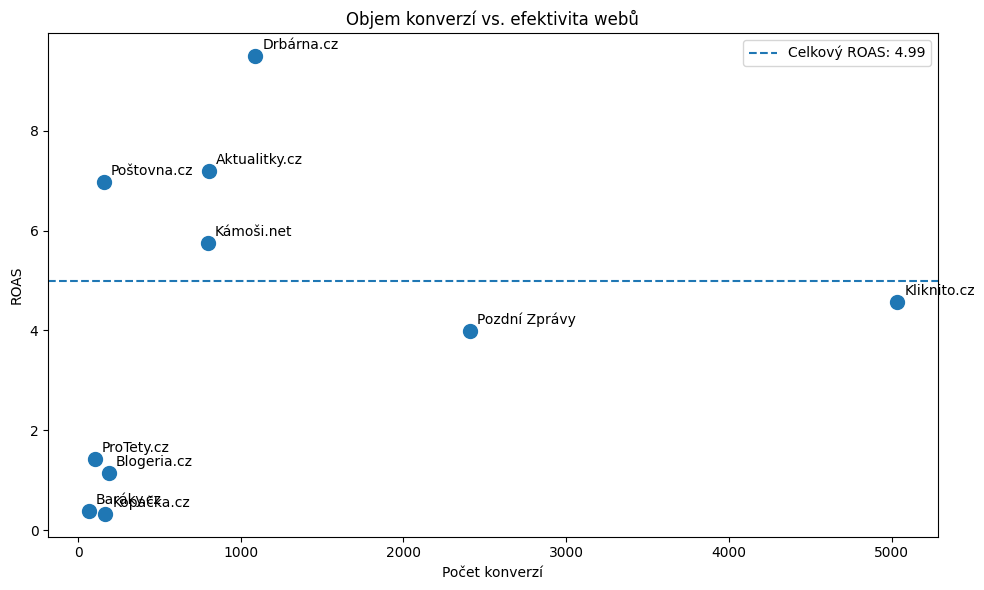

In [30]:
plt.figure(figsize=(10, 6))

plt.scatter(
    web_summary['conversions'],
    web_summary['roas'],
    s=100
)

for _, row in web_summary.iterrows():
    plt.annotate(
        row['WEB_NAME'],
        (row['conversions'], row['roas']),
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.axhline(
    total_roas,
    linestyle='--',
    label=f'Celkový ROAS: {total_roas:.2f}'
)

plt.title('Objem konverzí vs. efektivita webů')
plt.xlabel('Počet konverzí')
plt.ylabel('ROAS')
plt.legend()

plt.tight_layout()
plt.show()

Propojení objemu a efektivity ukazuje, že weby mají odlišné role v celkovém výkonu.

**Kliknito.cz** je hlavním zdrojem konverzí, ale jeho ROAS 4,58 je mírně pod celkovou úrovní 4,99. Web tedy přináší vysoký objem, ale s nižší efektivitou než některé menší weby.

**Drbárna.cz** kombinuje relativně vysoký počet konverzí s nejvyšším ROAS 9,49 a z tohoto pohledu patří mezi nejsilnější weby.

**Aktualitky.cz** a **Kámoši.net** mají nižší objem než největší weby, ale dosahují nadprůměrné efektivity.

Na opačné straně stojí zejména **Baráky.cz** a **Kopačka.cz**, které mají nižší objem a zároveň velmi nízký ROAS.

### 2.6 Hlavní zjištění

Z analyzovaného období vyplývá několik hlavních závěrů:

1. **Výkon je výrazně koncentrovaný do několika webů.**  
   Největší objem konverzí přináší Kliknito.cz, následované weby Pozdní Zprávy a Drbárna.cz.

2. **Největší objem neznamená automaticky nejvyšší efektivitu.**  
   Kliknito.cz je hlavním zdrojem konverzí, ale jeho ROAS 4,58 je mírně pod celkovým ROAS 4,99.

3. **Drbárna.cz kombinuje silný objem s velmi vysokou efektivitou.**  
   S ROAS 9,49 dosahuje nejlepšího výsledku mezi sledovanými weby a zároveň generuje více než tisíc konverzí.

4. **Některé menší weby dosahují nadprůměrné efektivity.**  
   Aktualitky.cz a Kámoši.net mají nižší objem než největší weby, ale jejich ROAS je nad celkovou úrovní datasetu.

5. **Baráky.cz a Kopačka.cz vykazují slabou efektivitu.**  
   Jejich ROAS je výrazně pod hodnotou 1, tedy vykázaná hodnota konverzí je nižší než vynaložené náklady.

### 2.7 Action points

- **Prověřit škálovatelnost webů s vysokým ROAS**, zejména Drbárna.cz, Aktualitky.cz a Kámoši.net, zda lze zvýšit objem při zachování současné efektivity.
- **Detailněji analyzovat weby s nízkým ROAS**, především Baráky.cz a Kopačka.cz, a zjistit, zda je nízká efektivita způsobena publikem, typem zařízení, reklamní sítí nebo jiným faktorem.
- **U Kliknito.cz ověřit prostor pro zlepšení efektivity**, protože web přináší nejvyšší objem konverzí, ale ROAS je mírně pod celkovým výsledkem datasetu.

### 2.8 Možné navazující analýzy

- **vývoj výkonu v čase** – zda jsou rozdíly mezi weby stabilní, nebo jsou ovlivněné konkrétními dny či obdobími,
- **výkon podle demografických charakteristik a krajů** – zda se některé weby výrazně liší strukturou publika,
- **výkon podle zařízení a operačního systému** – s ohledem na chybějící hodnoty v těchto dimenzích,
- **rozdíly podle reklamní sítě** – zda je výkon webů odlišný mezi jednotlivými typy reklamního prostoru,
- **detailnější analýzu nízkého ROAS** – zejména u webů Baráky.cz a Kopačka.cz,
- **potenciál pro škálování efektivních webů** – například zda lze zvýšit objem u webů s vysokým ROAS bez výrazného zhoršení efektivity.